# Distributed XGBoost Training and Serving with Ray

This tutorial runs an end-to-end distributed XGBoost workflow with Ray:

- Dataset preprocessing with Ray Data
- Distributed XGBoost training with Ray Train
- Model artifact serving and prediction

Note: Hyperparameter tuning is not covered in this tutorial.

## Prerequisites

Update Ray cluster configuration based on kubernetes cluster setup via Ray UI tile on the Tools & FrameWorks page
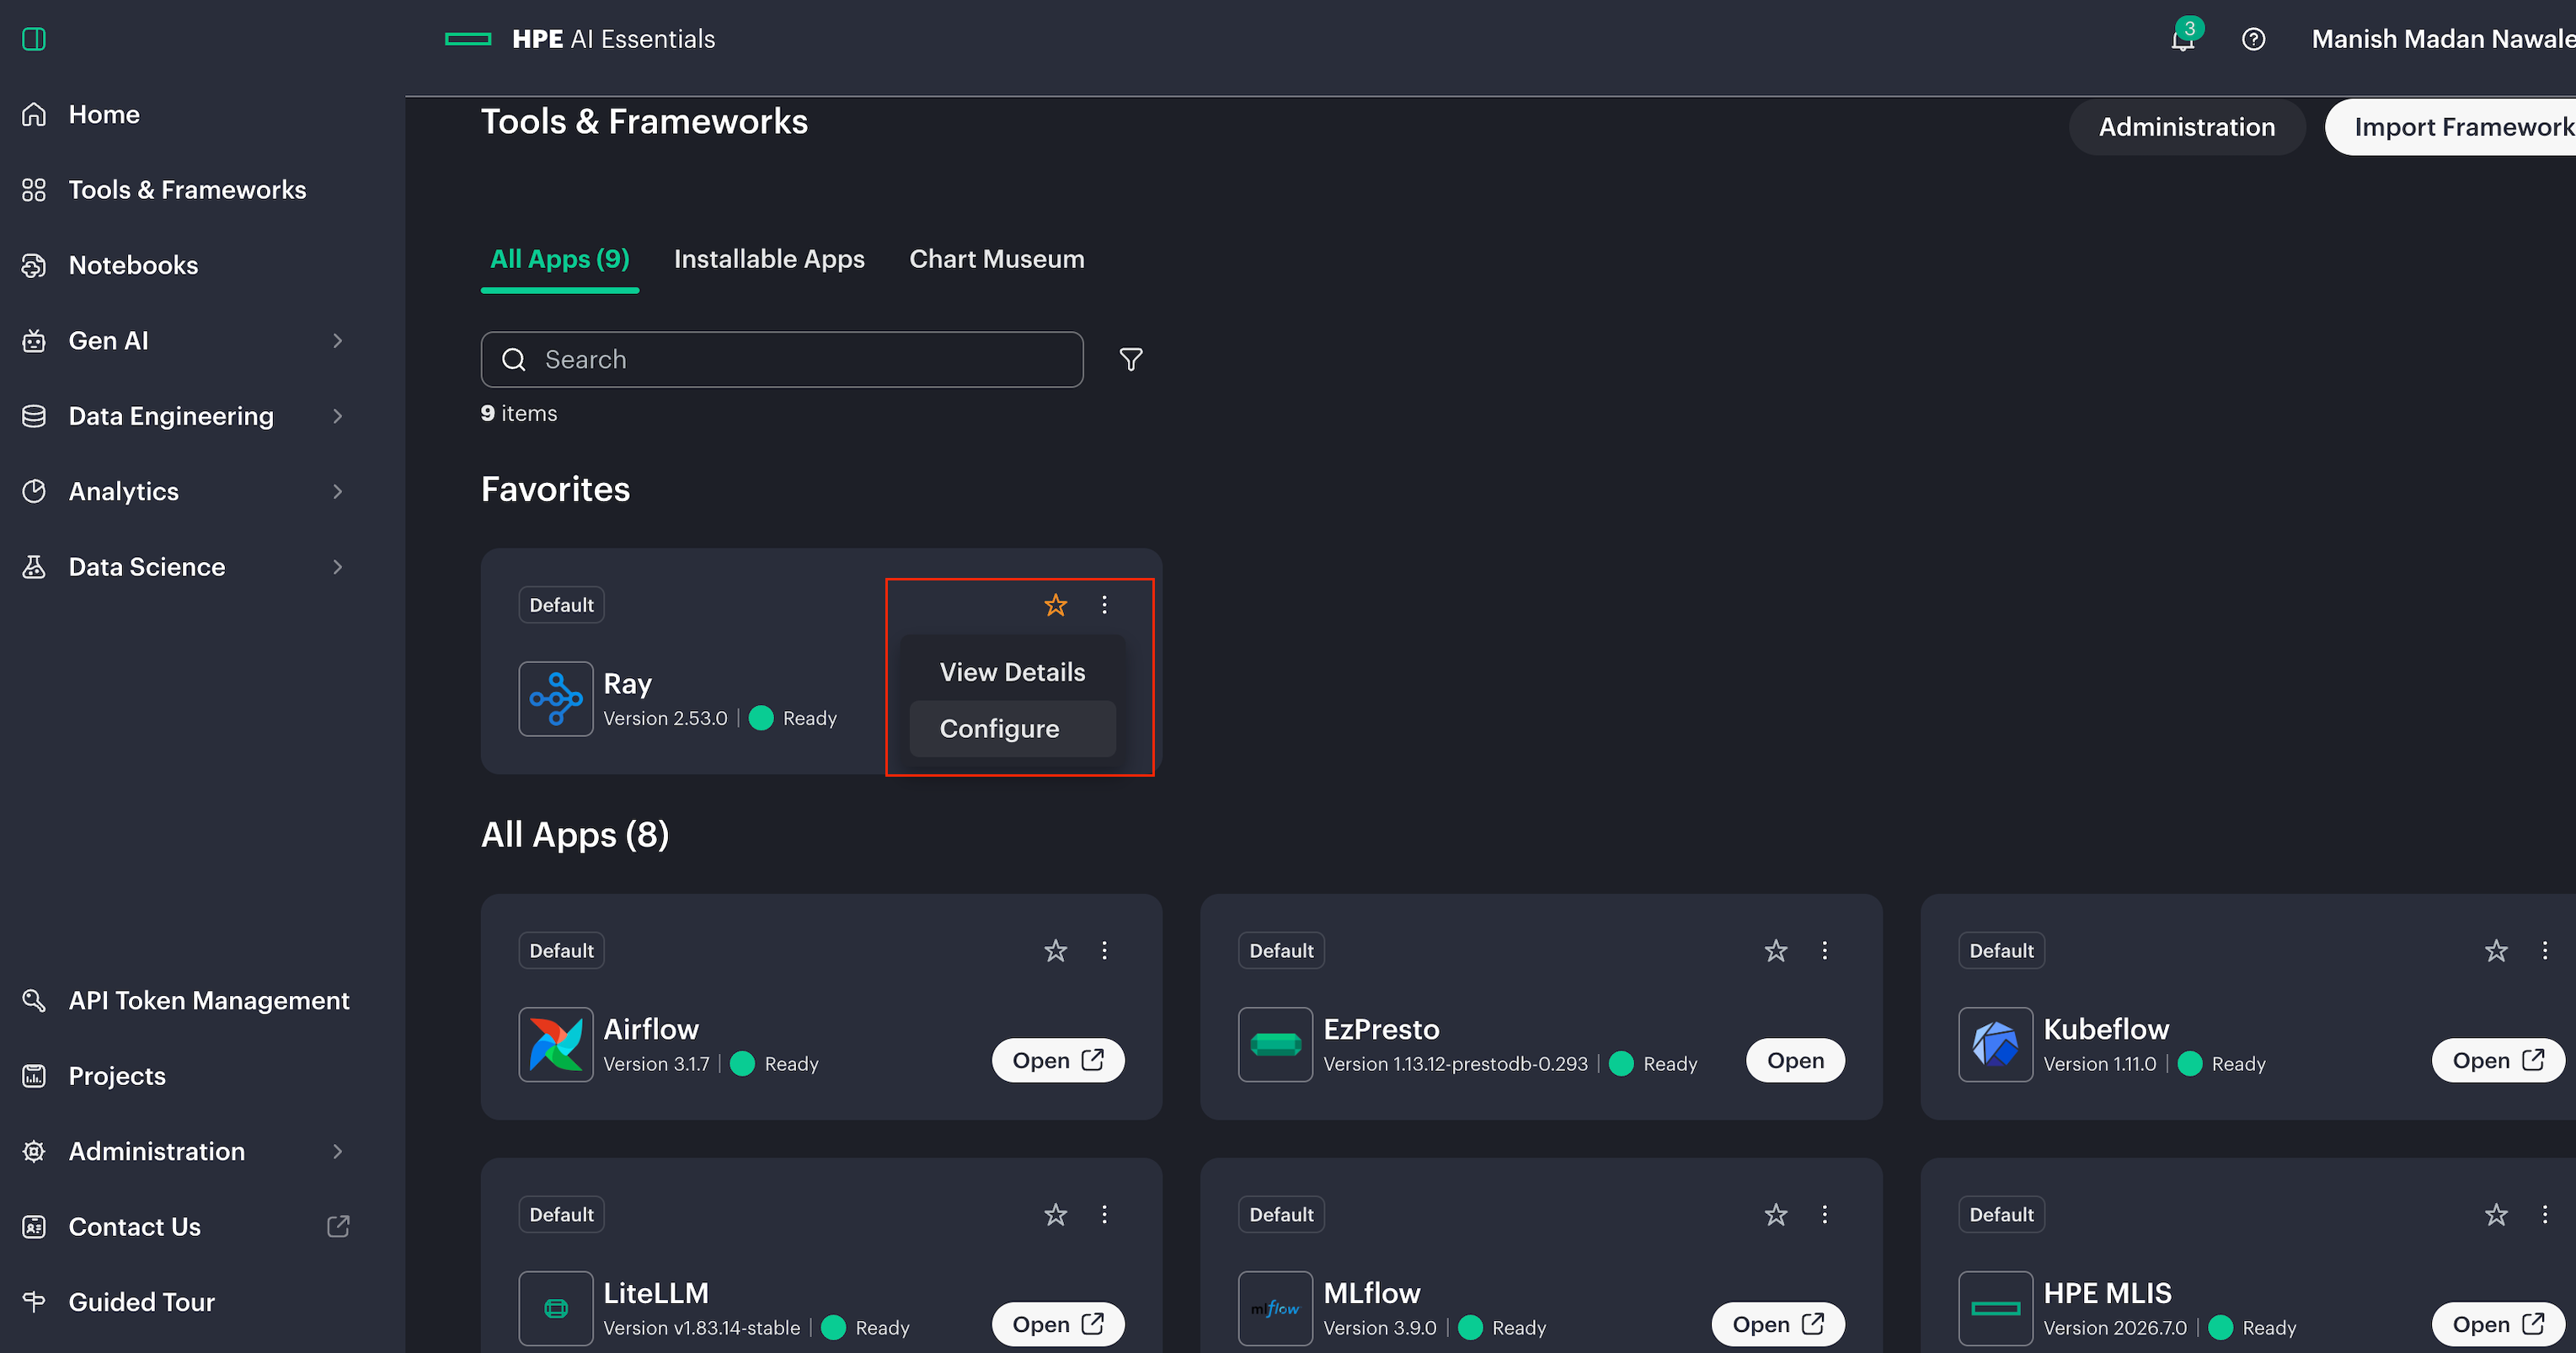


### Single-Node GPU Training

`Enable GPU`:

```yaml
###############################
## CONFIG | GLOBAL
###############################
global:
  gpu:
    enabled: "true"
```

`Disable smallGroup`:

```yaml
additionalWorkerGroups:
  smallGroup:
    disabled: true
    replicas: 0
    minReplicas: 0
    maxReplicas: 0
```

`Set worker resources`:

```yaml
worker:
  disabled: true
  groupName: workergroup
  replicas: 0
  minReplicas: 0
  maxReplicas: 1
  resources:
    limits:
      cpu: "8"
      memory: "16G"
    requests:
      cpu: "8"
      memory: "16G"
  resources_gpu:
    limits:
      cpu: "8"
      memory: "16G"
      nvidia.com/gpu: "1"
    requests:
      cpu: "8"
      memory: "8G"
      nvidia.com/gpu: "1"
```

### Single-Node CPU Training

`Disable GPU`:

```yaml
###############################
## CONFIG | GLOBAL
###############################
global:
  gpu:
    enabled: "false"
```

`Enable smallGroup and set maxReplicas to 1`:

```yaml
additionalWorkerGroups:
  smallGroup:
    disabled: false
    replicas: 0
    minReplicas: 0
    maxReplicas: 1
```

`Set worker resources`:

```yaml
additionalWorkerGroups:
  smallGroup:
    disabled: false
    replicas: 0
    minReplicas: 0
    maxReplicas: 1
    resources:
      limits:
        cpu: "8"
        memory: "16G"
      requests:
        cpu: "8"
        memory: "16G"
```

### Multi-Node Training

For multi-node training:

- Set `maxReplicas` to the number of Kubernetes worker nodes.
- Configure `podAntiAffinity` so only one Ray worker is scheduled per Kubernetes node.
- Update replicas and resources based on your cluster

#### Multi-Node GPU Training

`Enable GPU`:

```yaml
###############################
## CONFIG | GLOBAL
###############################
global:
  gpu:
    enabled: "true"
```

```yaml
worker:
  groupName: workergroup
  affinity:
    podAntiAffinity:
      requiredDuringSchedulingIgnoredDuringExecution:
        - labelSelector:
            matchLabels:
              ray.io/group: workerGroup
          topologyKey: kubernetes.io/hostname
```

#### Multi-Node CPU Training

```yaml
additionalWorkerGroups:
  smallGroup:
    affinity:
      podAntiAffinity:
        requiredDuringSchedulingIgnoredDuringExecution:
          - labelSelector:
              matchLabels:
                ray.io/group: smallGroup
            topologyKey: kubernetes.io/hostname
```

### Create client connection to remote ray cluster

In [20]:
import ray
import time
from ray.job_submission import JobSubmissionClient

ray_head_ip = "kuberay-head-svc.kuberay.svc.cluster.local"
ray_head_port = 8265
ray_address = f"http://{ray_head_ip}:{ray_head_port}"
client = JobSubmissionClient(ray_address)

In [21]:
# Check remote cluster connection 
!serve shutdown --address "http://kuberay-head-svc.kuberay.svc.cluster.local:8265" -y

2026-06-25 12:00:18,931	WARN scripts.py:766 -- No Serve instance found running on the cluster at http://kuberay-head-svc.kuberay.svc.cluster.local:8265.


### Submit Job to remote ray cluster

In [22]:
job_id = client.submit_job(
    entrypoint="python train_xgboost_model.py",
    runtime_env={
        "working_dir": "./",
        "env_vars": {"RAY_TRAIN_V2_ENABLED": "1"}
    },
    entrypoint_num_cpus=1
)

print(f"Ray job submitted with job_id: {job_id}")

# Waiting for Ray to finish the job and print the result
while True:
    status = client.get_job_status(job_id)
    if status in [ray.job_submission.JobStatus.RUNNING, ray.job_submission.JobStatus.PENDING]:
        time.sleep(5)
    else:
        break
try:
    logs = client.get_job_logs(job_id)
    print(logs)
except RuntimeError as e:
    print(f"Failed to get job logs, please check logs on ray dashboard ")
# We do not need this connection    
ray.shutdown()

2026-06-25 12:00:21,566	INFO dashboard_sdk.py:356 -- Uploading package gcs://_ray_pkg_b21793935a438e6f.zip.
2026-06-25 12:00:21,567	INFO packaging.py:691 -- Creating a file package for local module './'.


Ray job submitted with job_id: raysubmit_3Wve7nC7Hmwmi7yh
2026-06-25 05:00:21,677	INFO job_manager.py:579 -- Runtime env is setting up.
Running entrypoint for job raysubmit_3Wve7nC7Hmwmi7yh: python train_xgboost_model.py
2026-06-25 05:01:29,264	INFO worker.py:1680 -- Using address kuberay-head-svc.kuberay.svc.cluster.local:6379 set in the environment variable RAY_ADDRESS
2026-06-25 05:01:29,266	INFO worker.py:1821 -- Connecting to existing Ray cluster at address: kuberay-head-svc.kuberay.svc.cluster.local:6379...
2026-06-25 05:01:29,299	INFO worker.py:1998 -- Connected to Ray cluster. View the dashboard at http://10.224.27.230:8265 
/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-06-25 05

In [3]:
# Uncomment below command to update serve config
#!serve build --app-dir "./" serve_xgboost:xgboost_model -o xgboost_model_config.yaml

Module binding complete: `xgboost_model` is available for `serve build`.
2026-06-25 06:02:04,852	INFO scripts.py:886 -- The auto-generated application names default to `app1`, `app2`, ... etc. Rename as necessary.



## Attention!

- open the `xgboost_model_config.yaml` file and replace  working_dir: "zip_URI" with working_dir gcs package URI from job submission output
  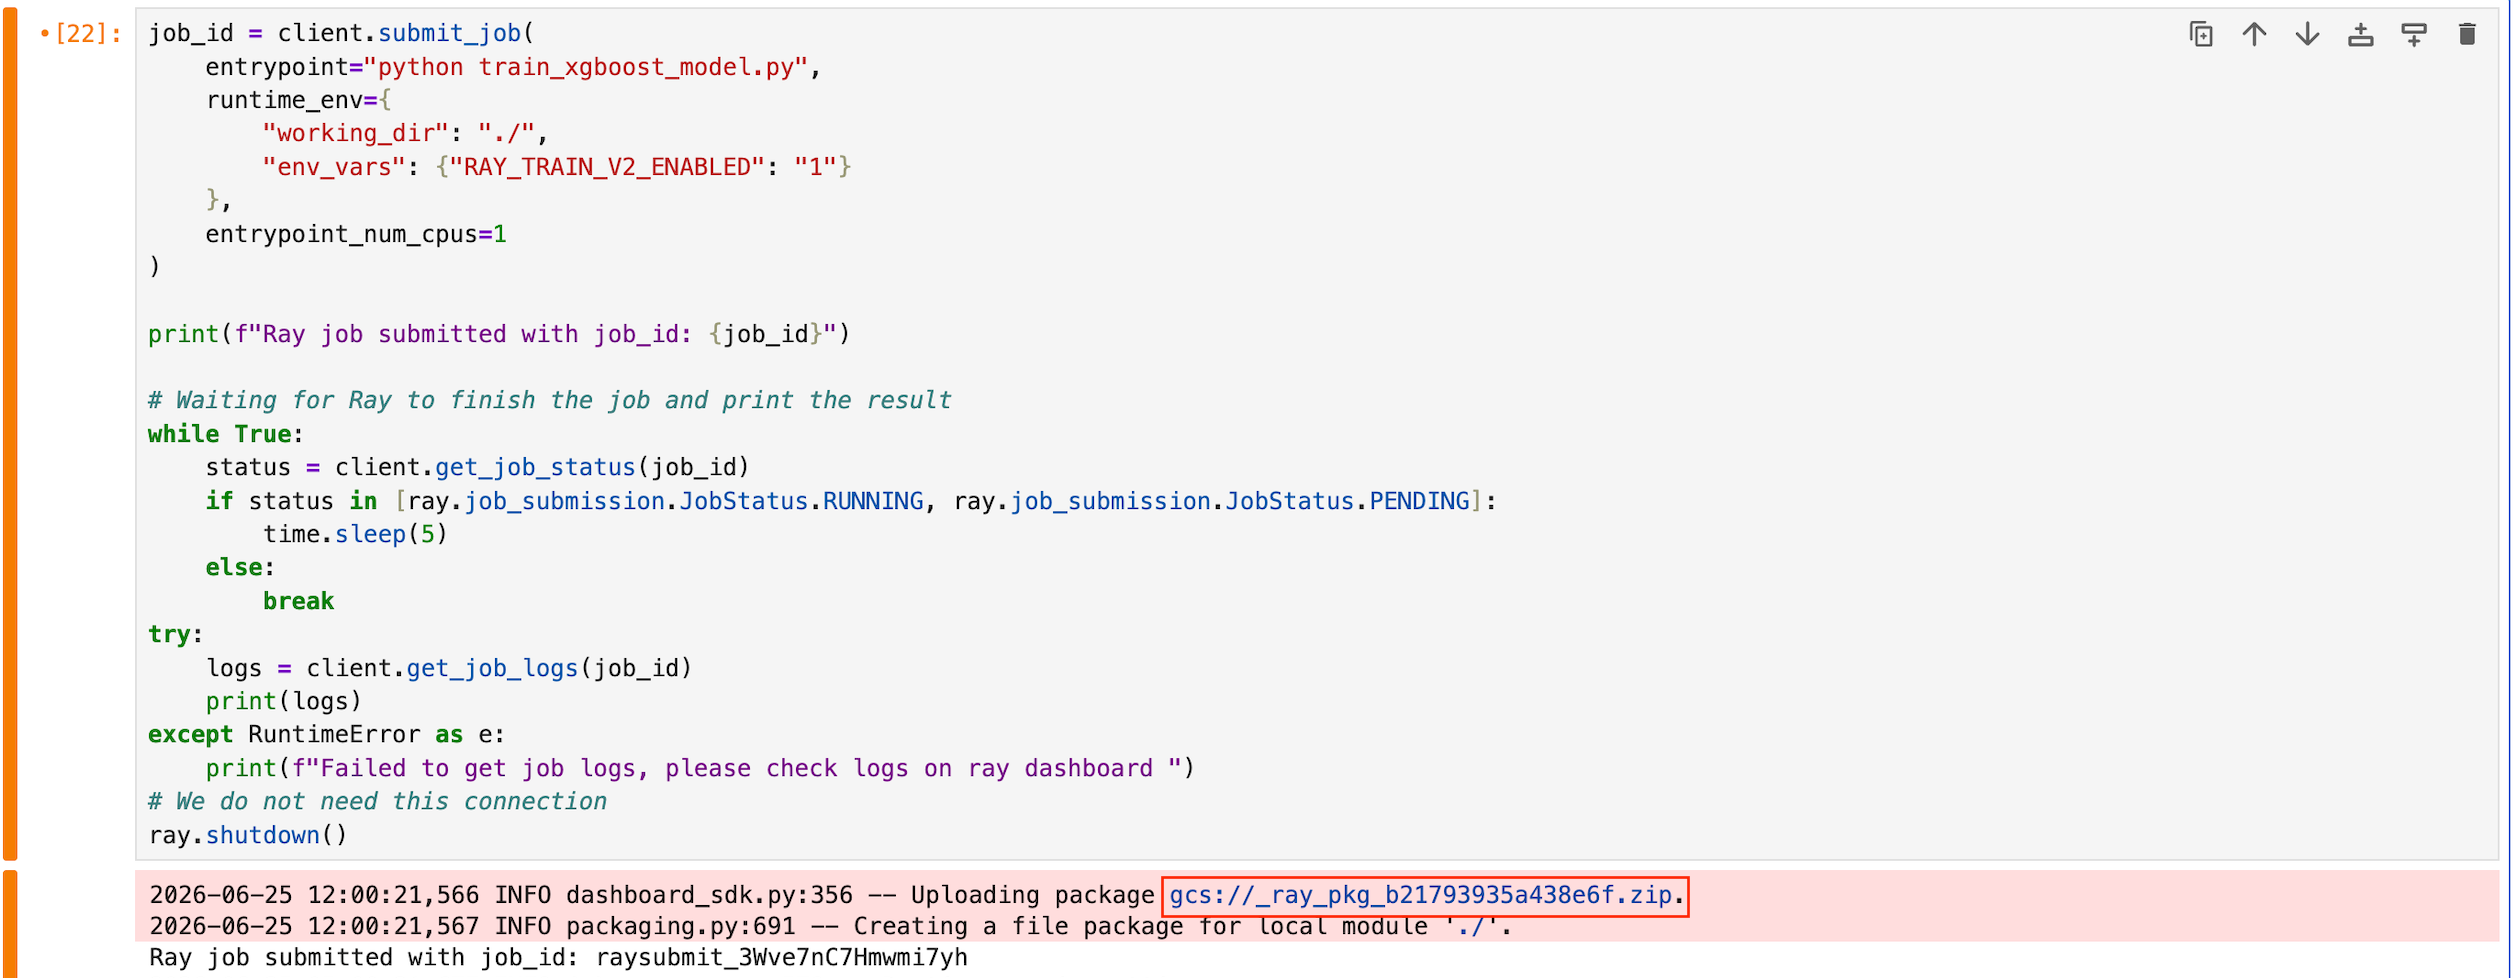


**xgboost_model_config.yaml**
```
applications:
- name: app1
  route_prefix: /
  import_path: serve_xgboost:xgboost_model
  runtime_env:
    working_dir: "gcs://_ray_pkg_b21793935a438e6f"
```

### Deploy trained model onto remote ray cluster using serve deploy 

In [23]:
!serve deploy --address "http://kuberay-head-svc.kuberay.svc.cluster.local:8265" xgboost_model_config.yaml

2026-06-25 12:05:43,523	INFO scripts.py:244 -- Deploying from config file: 'xgboost_model_config.yaml'.
2026-06-25 12:05:46,777	SUCC scripts.py:364 -- 
Sent deploy request successfully.
 * Use `serve status` to check applications' statuses.
 * Use `serve config` to see the current application config(s).



In [32]:
import requests
sample_input = {
    "mean radius": 5.9,
    "mean texture": 22.53,
    "mean perimeter": 102.1,
    "mean area": 685.0,
    "mean smoothness": 0.09947,
    "mean compactness": 0.2225,
    "mean concavity": 0.2733,
    "mean concave points": 0.09711,
    "mean symmetry": 0.2041,
    "mean fractal dimension": 0.06898,
    "radius error": 0.253,
    "texture error": 1.8749,
    "perimeter error": 3.466,
    "area error": 1.19,
    "smoothness error": 0.006965,
    "compactness error": 0.06213,
    "concavity error": 0.07926,
    "concave points error": 0.02234,
    "symmetry error": 0.01499,
    "fractal dimension error": 0.005784,
    "worst radius": 16.35,
    "worst texture": 27.57,
    "worst perimeter": 125.4,
    "worst area": 832.7,
    "worst smoothness": 0.1419,
    "worst compactness": 0.709,
    "worst concavity": 0.1319,
    "worst concave points": 0.2475,
    "worst symmetry": 0.2866,
    "worst fractal dimension": 0.1155,
}
sample_target = 0  # Ground truth label

### Run sample prediction requests

In [ ]:
try:
    response = requests.post("http://kuberay-head-svc.kuberay.svc.cluster.local:8000/", json=sample_input)
    print('Response status:', response.status_code)
    print(response.json())
except requests.exceptions.RequestException as e:
    print(f"Request failed: {e}")

In [34]:
!serve shutdown --address "http://kuberay-head-svc.kuberay.svc.cluster.local:8265" -y

2026-06-25 16:22:04,691	SUCC scripts.py:786 -- Sent shutdown request; applications will be deleted asynchronously.
